# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**Q1 Answers**
1. The idea is to prevent the model from getting too complex. If the coefficients get really large, the model is most likely overfitting the data. By adding a penalty for large coefficients, we force the model to stay simpler and more stable, which helps it perform better on new data.

2. Regularization increases bias a little but reduces variance a lot. Without it, the model might fit the training data too closely (low bias, high variance). With regularization, the model is slightly less flexible (higher bias), but it becomes more consistent across different datasets (lower variance), which improves overall performance.

3.
- Ridge (L2) shrinks coefficients toward zero but doesn’t make them exactly zero. So it keeps all variables in the model.
- LASSO (L1) can shrink some coefficients all the way to zero, which basically removes those variables.

  So, Ridge is better when most variables matter a little, while LASSO is useful when you think only a few variables are really important.

4. We usually standardize variables (mean = 0, standard deviation = 1). This is important because regularization depends on the size of coefficients, and if variables are on different scales, some will be penalized more than others unfairly.

5. We usually choose α using cross-validation. We try different values and pick the one that gives the lowest validation error.

6. No, we don’t include the penalty term. We only look at the prediction error (MSE) because we care about how well the model predicts new data. The penalty is just used during training to control the model, not to measure its performance.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [ ]:
!git clone https://github.com/Marco-Velazz/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 24 (delta 4), reused 4 (delta 4), pack-reused 16 (from 1)
Receiving objects: 100% (24/24), 25.56 KiB | 4.26 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Download complete
Extracting data files...
Data extracted


In [ ]:
import pandas as pd
import numpy as np

cars = pd.read_csv("/content/data/cars_hw.csv")

print("Columns:")
print(cars.columns.tolist())

cars["Age"] = 2026 - cars["Make_Year"]

print("\nPreview:")
print(cars[["Mileage_Run", "Make_Year", "Age"]].head())

print("\nMissing values:")
print(cars[["Mileage_Run", "Age", "Price"]].isnull().sum())

print("\nShape:", cars.shape)

Columns:
['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run', 'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission', 'Transmission_Type', 'Price']

Preview:
   Mileage_Run  Make_Year  Age
0        44611       2017    9
1        20305       2016   10
2        29540       2019    7
3        35680       2017    9
4        25126       2017    9

Missing values:
Mileage_Run    0
Age            0
Price          0
dtype: int64

Shape: (976, 13)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

X = cars[["Mileage_Run", "Age"]]
y = cars["Price"]

# Polynomial expansion (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
print("Polynomial Features:")
print(feature_names)

# Standardize (z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

print("\nShape after expansion:", X_scaled.shape)

Polynomial Features:
['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']

Shape after expansion: (976, 9)


In [ ]:
from sklearn.linear_model import LinearRegression

# Fit linear regression
lr = LinearRegression()
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr.coef_
})

print(coef_df)

             Feature   Coefficient
0        Mileage_Run  9.117748e+05
1                Age -2.481722e+05
2      Mileage_Run^2 -2.072926e+05
3    Mileage_Run Age -1.671212e+06
4              Age^2  3.505507e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  3.388195e+05
7  Mileage_Run Age^2  7.167816e+05
8              Age^3 -2.100379e+05


In [ ]:
from sklearn.linear_model import LassoCV

# Define alpha grid
alphas = np.logspace(1, 3, 20)

# Fit Lasso with 20-fold CV
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X_scaled, y)

print("Best alpha:", lasso_cv.alpha_)

Best alpha: 88.58667904100822


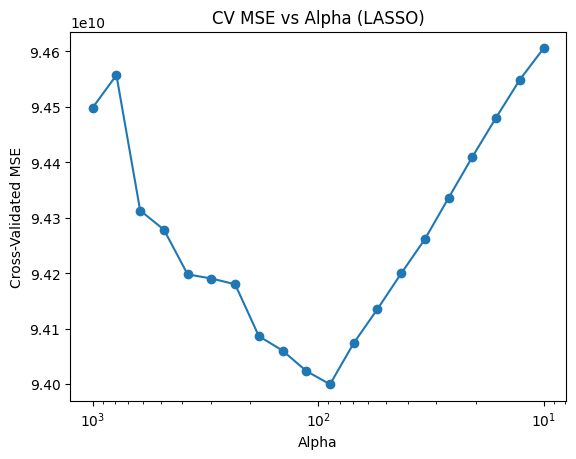

In [ ]:
import matplotlib.pyplot as plt

# Mean MSE across folds
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure()
plt.plot(lasso_cv.alphas_, mean_mse, marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE vs Alpha (LASSO)")
plt.gca().invert_xaxis()
plt.show()



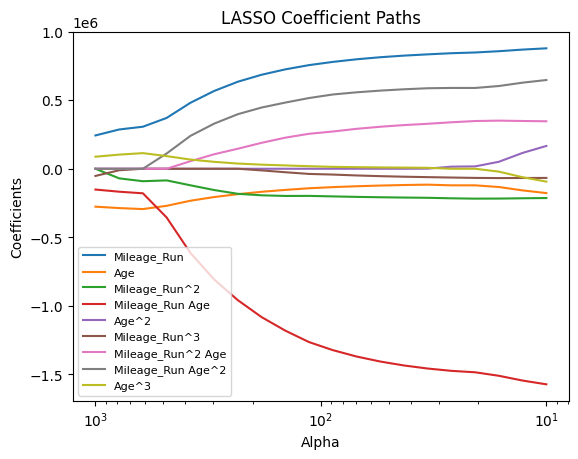

In [ ]:
from sklearn.linear_model import Lasso

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=feature_names[i])

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("LASSO Coefficient Paths")
plt.gca().invert_xaxis()
plt.legend(loc='best', fontsize=8)
plt.show()

In [ ]:
lasso_coefs = pd.DataFrame({
    "Feature": feature_names,
    "LASSO_Coefficient": lasso_cv.coef_
})

print(lasso_coefs)

             Feature  LASSO_Coefficient
0        Mileage_Run       7.790762e+05
1                Age      -1.339534e+05
2      Mileage_Run^2      -2.015634e+05
3    Mileage_Run Age      -1.322419e+06
4              Age^2       0.000000e+00
5      Mileage_Run^3      -4.240952e+04
6  Mileage_Run^2 Age       2.715062e+05
7  Mileage_Run Age^2       5.415432e+05
8              Age^3       1.374220e+04


**Q2 Answers**

Qusetion 2. Negative

Question 6. LASSO keeps all features except:

    - Age² (this one is set to 0)

    So the selected features are:

    - Mileage_Run
    - Age
    - Mileage_Run²
    - Mileage_Run × Age
    - Mileage_Run³
    - Mileage_Run² × Age
    - Mileage_Run × Age²
    - Age³  

    and the proportion = 1 / 9 ≈ 0.11 (11%)

Question 7. No, all coefficients either shrink in size or go to zero, and all coefficients keep the same sign as in linear regression.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [ ]:
import pandas as pd
import numpy as np

heart = pd.read_csv("/content/data/heart_failure_clinical_records_dataset.csv")

print("Shape:", heart.shape)
print("\nColumns:")
print(heart.columns.tolist())

print("\nFirst 5 rows:")
print(heart.head())

print("\nMissing values:")
print(heart.isnull().sum())

Shape: (299, 13)

Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

First 5 rows:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                 

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Continuous variables
X_cont = heart[["age", "ejection_fraction", "serum_creatinine"]]

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)

cont_feature_names = poly_cont.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])

print("Continuous polynomial features:")
print(cont_feature_names)

# Categorical (binary) variables
X_cat = heart[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_poly = poly_cat.fit_transform(X_cat)

cat_feature_names = poly_cat.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])

print("\nCategorical interaction features:")
print(cat_feature_names)

# Combine features
X_all = np.hstack([X_cont_poly, X_cat_poly])
feature_names = np.concatenate([cont_feature_names, cat_feature_names])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Target
y = heart["DEATH_EVENT"]

print("\nFinal shape:", X_scaled.shape)

Continuous polynomial features:
['age' 'ejection_fraction' 'serum_creatinine' 'age^2'
 'age ejection_fraction' 'age serum_creatinine' 'ejection_fraction^2'
 'ejection_fraction serum_creatinine' 'serum_creatinine^2' 'age^3'
 'age^2 ejection_fraction' 'age^2 serum_creatinine'
 'age ejection_fraction^2' 'age ejection_fraction serum_creatinine'
 'age serum_creatinine^2' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine'
 'ejection_fraction serum_creatinine^2' 'serum_creatinine^3']

Categorical interaction features:
['anaemia' 'diabetes' 'high_blood_pressure' 'smoking' 'anaemia diabetes'
 'anaemia high_blood_pressure' 'anaemia smoking'
 'diabetes high_blood_pressure' 'diabetes smoking'
 'high_blood_pressure smoking']

Final shape: (299, 29)


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr.coef_
})

print(coef_df)

                                   Feature  Coefficient
0                                      age     1.539156
1                        ejection_fraction    -2.192494
2                         serum_creatinine    -0.853588
3                                    age^2    -3.678654
4                    age ejection_fraction    -0.600918
5                     age serum_creatinine     1.841563
6                      ejection_fraction^2     3.430976
7       ejection_fraction serum_creatinine     2.673394
8                       serum_creatinine^2    -2.647041
9                                    age^3     1.993135
10                 age^2 ejection_fraction     0.908026
11                  age^2 serum_creatinine    -0.697522
12                 age ejection_fraction^2    -0.081206
13  age ejection_fraction serum_creatinine    -1.577665
14                  age serum_creatinine^2     1.284099
15                     ejection_fraction^3    -1.250341
16    ejection_fraction^2 serum_creatinine    -1

In [ ]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X_scaled, y)

print("Best alpha:", lasso_cv.alpha_)

Best alpha: 0.005736152510448681


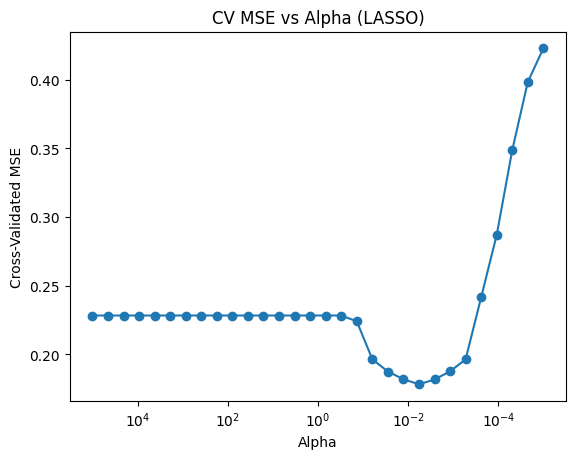

In [ ]:
import matplotlib.pyplot as plt

mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure()
plt.plot(lasso_cv.alphas_, mean_mse, marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE vs Alpha (LASSO)")
plt.gca().invert_xaxis()
plt.show()

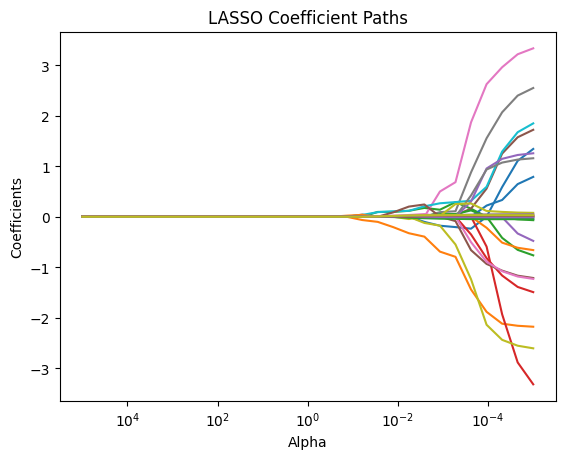

In [ ]:
from sklearn.linear_model import Lasso

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("LASSO Coefficient Paths")
plt.gca().invert_xaxis()
plt.show()

In [ ]:
lasso_coefs = pd.DataFrame({
    "Feature": feature_names,
    "LASSO_Coefficient": lasso_cv.coef_
})

print(lasso_coefs)

                                   Feature  LASSO_Coefficient
0                                      age          -0.000000
1                        ejection_fraction          -0.326124
2                         serum_creatinine           0.117426
3                                    age^2           0.000000
4                    age ejection_fraction          -0.000000
5                     age serum_creatinine           0.000000
6                      ejection_fraction^2           0.000000
7       ejection_fraction serum_creatinine           0.000000
8                       serum_creatinine^2          -0.000000
9                                    age^3           0.116214
10                 age^2 ejection_fraction           0.000000
11                  age^2 serum_creatinine           0.000000
12                 age ejection_fraction^2           0.000000
13  age ejection_fraction serum_creatinine           0.000000
14                  age serum_creatinine^2          -0.000000
15      

**Q3 Answers**

Question 2. Yes, there are some counterintuitive signs. For example: serum_creatinine is negative in linear regression, even though higher creatinine should increase death risk smoking and high_blood_pressure are also negative, which doesn’t make sense. This happens because of multicollinearity (variables are correlated with each other) and the model trying to split effects across many related features. So individual coefficients can look misleading even if the overall prediction is correct.
Including polynomial terms (like squared/cubed) and interaction terms, it helps the model capture nonlinear relationships and combined effects between variables. So even if a single coefficient looks wrong, the combined effect of multiple terms can correctly reflect the real relationship.

Question 6. LASSO selects a smaller subset of features by shrinking many coefficients to zero. In this case, 12 out of 29 features are kept, while 17 are set to zero, meaning about 59% of the features are removed. Compared to linear regression, LASSO does not increase the magnitude of coefficients; instead, it shrinks them or eliminates them entirely, and the signs of the remaining coefficients generally stay the same. Overall, the LASSO model makes more sense because it simplifies the model by removing less important variables, leading to more stable and interpretable results. This connects to the bias-variance tradeoff, where linear regression has low bias but high variance and tends to overfit, while LASSO introduces a bit more bias but greatly reduces variance, resulting in better generalization and more reliable coefficient estimates.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

**Q4 Answers**
1. $$
\frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha (b_1)^2
$$

2. $$
b_0 = 0
$$

                                                                   and

$$
b_1 = \frac{\sum_{i=1}^n \tilde{x}_i \tilde{y}_i}{\sum_{i=1}^n \tilde{x}_i^2 + \alpha}
$$

3. As *a* increases, *b1* shrinks toward 0.

4. The absolute value is not differentiable at 0, so *b1* = 0 is optimal when the correlation between *x* and *y* is small relative to *a*.